# YOLOv10n 2차 Fine-tuning (직접 수집한 노인 손 데이터)

1차 학습된 가중치(`hagrid_stage1_8cls_best.pt`)를 베이스로,
직접 수집한 노인 손 데이터를 추가 학습함.

YOLO는 PyTorch Dataset/DataLoader를 직접 안 쓰고, `model.train()` 호출 시
augmentation 파라미터를 인자로 넘기는 방식임. 아래에서 좌우반전, 밝기/대비,
회전 등을 그 방식대로 설정함.

## 0. 환경 설정

In [ ]:
!pip install ultralytics

In [ ]:
import torch
print("GPU 사용 가능:", torch.cuda.is_available())
print("GPU 이름:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음")

GPU 사용 가능: True
GPU 이름: Tesla T4


## 1. Drive 마운트 및 데이터 연결

1차 학습 가중치 + 노인 손 데이터셋(YOLO 포맷, images/labels) 둘 다 Drive에서 가져옴.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# CONFIG — 여기만 수정하면 됨
# ============================================================

# 1차 학습 가중치 (Drive에 백업해둔 것)
STAGE1_WEIGHTS = "/content/drive/MyDrive/HandSpark/hagrid_stage1_8cls_best.pt"

# 노인 손 데이터셋 zip (직접 촬영 + 라벨링한 YOLO 포맷, images/labels/dataset.yaml 포함)
DRIVE_ELDERLY_DATASET_ZIP = "/content/drive/MyDrive/HandSpark/OSSP-Labeling.coco.zip"

# 압축 풀 위치
LOCAL_DATA_DIR = "/content/data/elderly_hand_yolo"

# ============================================================

In [ ]:
import os

os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
!unzip -q "{DRIVE_ELDERLY_DATASET_ZIP}" -d "{LOCAL_DATA_DIR}"

print("압축 해제 완료. 폴더 구조 확인:")
for root, dirs, files in os.walk(LOCAL_DATA_DIR):
    level = root.replace(LOCAL_DATA_DIR, "").count(os.sep)
    if level > 2:
        continue
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

replace /content/data/elderly_hand_yolo/train/promise_010_jpg.rf.XwQ0MNBB8oFaJ6eIP8Z7.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
압축 해제 완료. 폴더 구조 확인:
elderly_hand_yolo/
  valid/
  train/
  test/


In [ ]:
!cp "/content/drive/MyDrive/HandSpark/Copy of dataset.yaml" "{LOCAL_DATA_DIR}/dataset.yaml"
print("yaml 복사 완료")

yaml 복사 완료


## 2. dataset.yaml 확인

주의: 압축 구조에 따라 한 단계 더 들어간 폴더가 생길 수 있음(1차 학습 때처럼).
아래 셀 실행 후 경로가 안 맞으면 `LOCAL_DATA_DIR`에 하위 폴더명을 추가할 것.

In [ ]:
DATASET_YAML = f"{LOCAL_DATA_DIR}/dataset.yaml"

print("존재 여부:", os.path.exists(DATASET_YAML))
if os.path.exists(DATASET_YAML):
    with open(DATASET_YAML, "r") as f:
        print(f.read())

존재 여부: True
path: C:\Users\riwon\Downloads\data\hagrid_yolo
train: images/train
val: images/val
test: images/test

names:
  0: palm
  1: fist
  2: ok
  3: three
  4: like
  5: call
  6: rock
  7: three2
  # 8: three_gun



In [ ]:
# path 줄만 코랩 경로로 자동 교체 (names는 그대로 유지)
with open(DATASET_YAML, "r") as f:
    lines = f.readlines()

with open(DATASET_YAML, "w") as f:
    for line in lines:
        if line.startswith("path:"):
            f.write(f"path: {LOCAL_DATA_DIR}\n")
        else:
            f.write(line)

print("수정된 dataset.yaml:")
with open(DATASET_YAML, "r") as f:
    print(f.read())

수정된 dataset.yaml:
path: /content/data/elderly_hand_yolo
train: images/train
val: images/val
test: images/test

names:
  0: palm
  1: fist
  2: ok
  3: three
  4: like
  5: call
  6: rock
  7: three2
  # 8: three_gun



## 3. 증강(Augmentation) 및 학습 설정

YOLO의 `model.train()`은 아래 파라미터들로 증강을 자동 적용함
(별도 transform 코드 작성 불필요, 인자로만 제어):

| 파라미터 | 의미 | 노인 손 데이터에 맞춘 이유 |
|---|---|---|
| `fliplr` | 좌우 반전 확률 | 왼손/오른손 둘 다 학습되도록 |
| `flipud` | 상하 반전 확률 | 손은 상하반전하면 부자연스러워 0으로 둠 |
| `hsv_h/s/v` | 색조/채도/명도 변화 | 조명 환경 다양성 대응 |
| `degrees` | 회전 각도 | 손 각도가 정면이 아닐 수 있어 약간 부여 |
| `translate` | 이동 | 화면 중앙이 아닌 위치 대응 |
| `scale` | 크기 변화 | 카메라 거리 차이 대응 |
| `shear` | 기울임 | 약간의 왜곡 대응 |
| `mosaic` | 모자이크 합성 | 배경 다양성, 기본값 유지 |
| `mixup` | 이미지 혼합 | 데이터 적을 때 과적합 방지에 도움 |

노인 손 떨림/관절 변형 데이터 특성상, 너무 강한 회전/왜곡은 실제 형태를 왜곡시킬 수 있어
기본값보다 약간 보수적으로 잡음. 필요하면 직접 조정할 것.

In [ ]:
# ============================================================
# CONFIG — 여기만 수정하면 됨
# ============================================================

EPOCHS = 60
IMG_SIZE = 640
BATCH_SIZE = 16
RUN_NAME = "hagrid_stage2_elderly"
PROJECT_DIR = "/content/runs/detect/runs"   # 1차 때 확인된 실제 경로 패턴 반영

# 1차보다 낮은 학습률로 시작 (이미 학습된 가중치를 미세조정하는 거라)
LR0 = 0.001

# 증강 설정
AUGMENT_CONFIG = dict(
    fliplr=0.5,       # 좌우 반전 (왼손/오른손 대응)
    flipud=0.0,       # 상하 반전 안 함
    hsv_h=0.015,       # 색조 변화 (기본값)
    hsv_s=0.5,        # 채도 변화 (조명 대응, 기본보다 약간 낮춤)
    hsv_v=0.4,        # 명도 변화 (조명 대응)
    degrees=10.0,     # 회전 +-10도 (손 각도 다양성, 과하지 않게)
    translate=0.1,    # 이동 10%
    scale=0.3,        # 크기 변화 (카메라 거리 대응)
    shear=2.0,        # 약간의 기울임
    mosaic=1.0,       # 기본값 유지
    mixup=0.1,        # 데이터 적을 때 과적합 방지용으로 약간 부여
)

# ============================================================

In [ ]:
import os

print("파일 크기:", os.path.getsize(STAGE1_WEIGHTS), "bytes")
print("\n파일 앞 200바이트:")
with open(STAGE1_WEIGHTS, "rb") as f:
    print(f.read(200))

파일 크기: 5737210 bytes

파일 앞 200바이트:
b'PK\x03\x04\x00\x00\x08\x08\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\r\x00\x15\x00best/data.pklFB\x11\x00ZZZZZZZZZZZZZZZZZ\x80\x02}q\x00(X\x04\x00\x00\x00dateq\x01X\x1a\x00\x00\x002026-06-18T06:01:57.582183q\x02X\x07\x00\x00\x00versionq\x03X\x06\x00\x00\x008.4.70q\x04X\x07\x00\x00\x00licenseq\x05X*\x00\x00\x00AGPL-3.0 (https://ultralytics.com/licens'


## 4. 1차 가중치 로드 후 2차 Fine-tuning

In [ ]:
from ultralytics import YOLO

model = YOLO(STAGE1_WEIGHTS)
print(f"1차 가중치 로드 완료: {STAGE1_WEIGHTS}")

1차 가중치 로드 완료: /content/drive/MyDrive/HandSpark/hagrid_stage1_8cls_best.pt


In [ ]:
import glob

print("=== 전체 폴더 구조 ===")
!find {LOCAL_DATA_DIR} -maxdepth 3 -type d

print("\n=== 파일 종류별 개수 ===")
print("이미지 (.jpg/.png):", len(glob.glob(f"{LOCAL_DATA_DIR}/**/*.jpg", recursive=True)) + len(glob.glob(f"{LOCAL_DATA_DIR}/**/*.png", recursive=True)))
print("라벨 txt:", len(glob.glob(f"{LOCAL_DATA_DIR}/**/*.txt", recursive=True)))
print("라벨 json:", len(glob.glob(f"{LOCAL_DATA_DIR}/**/*.json", recursive=True)))

print("\n=== json 파일 위치 ===")
for j in glob.glob(f"{LOCAL_DATA_DIR}/**/*.json", recursive=True):
    print(" -", j)

=== 전체 폴더 구조 ===
/content/data/elderly_hand_yolo
/content/data/elderly_hand_yolo/valid
/content/data/elderly_hand_yolo/train
/content/data/elderly_hand_yolo/test

=== 파일 종류별 개수 ===
이미지 (.jpg/.png): 398
라벨 txt: 2
라벨 json: 3

=== json 파일 위치 ===
 - /content/data/elderly_hand_yolo/valid/_annotations.coco.json
 - /content/data/elderly_hand_yolo/train/_annotations.coco.json
 - /content/data/elderly_hand_yolo/test/_annotations.coco.json


In [ ]:
import json, shutil
from pathlib import Path

# 1차 학습 클래스 순서 (절대 바꾸지 말 것)
STAGE1_CLASSES = ["palm", "fist", "ok", "three", "like", "call", "rock", "three2"]
NAME_TO_ID = {name: i for i, name in enumerate(STAGE1_CLASSES)}

SRC_DIR = Path(LOCAL_DATA_DIR)
DST_DIR = Path("/content/data/elderly_yolo_converted")

# 원본 폴더명 → YOLO 표준 폴더명
SPLITS = {"train": "train", "valid": "val", "test": "test"}

# 출력 폴더 생성
for dst in SPLITS.values():
    (DST_DIR / "images" / dst).mkdir(parents=True, exist_ok=True)
    (DST_DIR / "labels" / dst).mkdir(parents=True, exist_ok=True)

for src_split, dst_split in SPLITS.items():
    json_path = SRC_DIR / src_split / "_annotations.coco.json"
    if not json_path.exists():
        print(f"⚠️ {json_path} 없음, 건너뜀")
        continue

    with open(json_path) as f:
        coco = json.load(f)

    # COCO categories 확인 + 이름 기반으로 1차 yaml ID에 매핑
    print(f"\n[{src_split}] COCO categories:")
    coco_cat_to_yaml_id = {}
    unmapped = []
    for cat in coco["categories"]:
        name = cat["name"]
        if name in NAME_TO_ID:
            coco_cat_to_yaml_id[cat["id"]] = NAME_TO_ID[name]
            print(f"  ✅ id={cat['id']} '{name}' → yaml id={NAME_TO_ID[name]}")
        else:
            unmapped.append(name)
            print(f"  ⏭️  id={cat['id']} '{name}' (1차 클래스에 없음, 건너뜀)")

    img_info = {img["id"]: img for img in coco["images"]}
    anns_by_img = {}
    for ann in coco["annotations"]:
        anns_by_img.setdefault(ann["image_id"], []).append(ann)

    converted = 0
    for img_id, info in img_info.items():
        fname = info["file_name"]
        W, H = info["width"], info["height"]
        src_img = SRC_DIR / src_split / fname
        if not src_img.exists():
            continue
        shutil.copy(src_img, DST_DIR / "images" / dst_split / fname)

        lines = []
        for ann in anns_by_img.get(img_id, []):
            yid = coco_cat_to_yaml_id.get(ann["category_id"])
            if yid is None:
                continue
            x, y, w, h = ann["bbox"]   # COCO: 픽셀 [x_min, y_min, w, h]
            cx, cy = (x + w/2)/W, (y + h/2)/H
            nw, nh = w/W, h/H
            lines.append(f"{yid} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        with open(DST_DIR / "labels" / dst_split / (Path(fname).stem + ".txt"), "w") as f:
            f.write("\n".join(lines))
        converted += 1
    print(f"  → {converted}개 변환 완료")

# 새 dataset.yaml 작성
yaml_text = f"""path: {DST_DIR}
train: images/train
val: images/val
test: images/test
names:
  0: palm
  1: fist
  2: ok
  3: three
  4: like
  5: call
  6: rock
  7: three2
"""
new_yaml = DST_DIR / "dataset.yaml"
new_yaml.write_text(yaml_text)
print(f"\n✅ 새 yaml: {new_yaml}")
print(yaml_text)

# 학습 셀이 이 새 yaml을 쓰도록 변수 덮어쓰기
DATASET_YAML = str(new_yaml)
LOCAL_DATA_DIR = str(DST_DIR)
print(f"DATASET_YAML 갱신됨: {DATASET_YAML}")


[train] COCO categories:
  ⏭️  id=0 'OSSP-Labeling' (1차 클래스에 없음, 건너뜀)
  ✅ id=1 'call' → yaml id=5
  ✅ id=2 'fist' → yaml id=1
  ✅ id=3 'like' → yaml id=4
  ✅ id=4 'ok' → yaml id=2
  ✅ id=5 'palm' → yaml id=0
  ✅ id=6 'rock' → yaml id=6
  ✅ id=7 'three' → yaml id=3
  ✅ id=8 'three2' → yaml id=7
  ⏭️  id=9 'three_gun' (1차 클래스에 없음, 건너뜀)
  → 281개 변환 완료

[valid] COCO categories:
  ⏭️  id=0 'OSSP-Labeling' (1차 클래스에 없음, 건너뜀)
  ✅ id=1 'call' → yaml id=5
  ✅ id=2 'fist' → yaml id=1
  ✅ id=3 'like' → yaml id=4
  ✅ id=4 'ok' → yaml id=2
  ✅ id=5 'palm' → yaml id=0
  ✅ id=6 'rock' → yaml id=6
  ✅ id=7 'three' → yaml id=3
  ✅ id=8 'three2' → yaml id=7
  ⏭️  id=9 'three_gun' (1차 클래스에 없음, 건너뜀)
  → 78개 변환 완료

[test] COCO categories:
  ⏭️  id=0 'OSSP-Labeling' (1차 클래스에 없음, 건너뜀)
  ✅ id=1 'call' → yaml id=5
  ✅ id=2 'fist' → yaml id=1
  ✅ id=3 'like' → yaml id=4
  ✅ id=4 'ok' → yaml id=2
  ✅ id=5 'palm' → yaml id=0
  ✅ id=6 'rock' → yaml id=6
  ✅ id=7 'three' → yaml id=3
  ✅ id=8 'three2' → yaml id=7
  

In [ ]:
RUN_NAME = "hagrid_stage2_elderly-2"

# 확인
weights_dir = f"{PROJECT_DIR}/{RUN_NAME}/weights"
print(os.listdir(weights_dir))

['last.pt', 'best.pt']


In [ ]:
results = model.train(
    data=DATASET_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    lr0=LR0,
    name=RUN_NAME,
    project=PROJECT_DIR,
    patience=15,
    save=True,
    plots=True,
    **AUGMENT_CONFIG,
)

KeyError: 'model'

In [ ]:
import os
weights_dir = f"{PROJECT_DIR}/{RUN_NAME}/weights"
print(os.listdir(weights_dir))

[]


In [ ]:
import os

# 실제로 runs 폴더가 어디 있는지 찾기
!find /content -name "best.pt" 2>/dev/null
!find /content -name "last.pt" 2>/dev/null

# PROJECT_DIR 변수 현재 값도 확인
print("PROJECT_DIR:", PROJECT_DIR)
print("RUN_NAME:", RUN_NAME)

/content/runs/detect/runs/hagrid_stage2_elderly-2/weights/best.pt
/content/runs/detect/runs/hagrid_stage2_elderly-2/weights/last.pt
PROJECT_DIR: /content/runs/detect/runs
RUN_NAME: hagrid_stage2_elderly


## 5. 결과 확인

In [ ]:
run_dir = f"{PROJECT_DIR}/{RUN_NAME}"
weights_dir = f"{run_dir}/weights"

print("가중치 파일 목록:")
for f in os.listdir(weights_dir):
    print(" -", f)

print(f"\n최종 가중치 경로: {weights_dir}/best.pt")

가중치 파일 목록:
 - last.pt
 - best.pt

최종 가중치 경로: /content/runs/detect/runs/hagrid_stage2_elderly-2/weights/best.pt


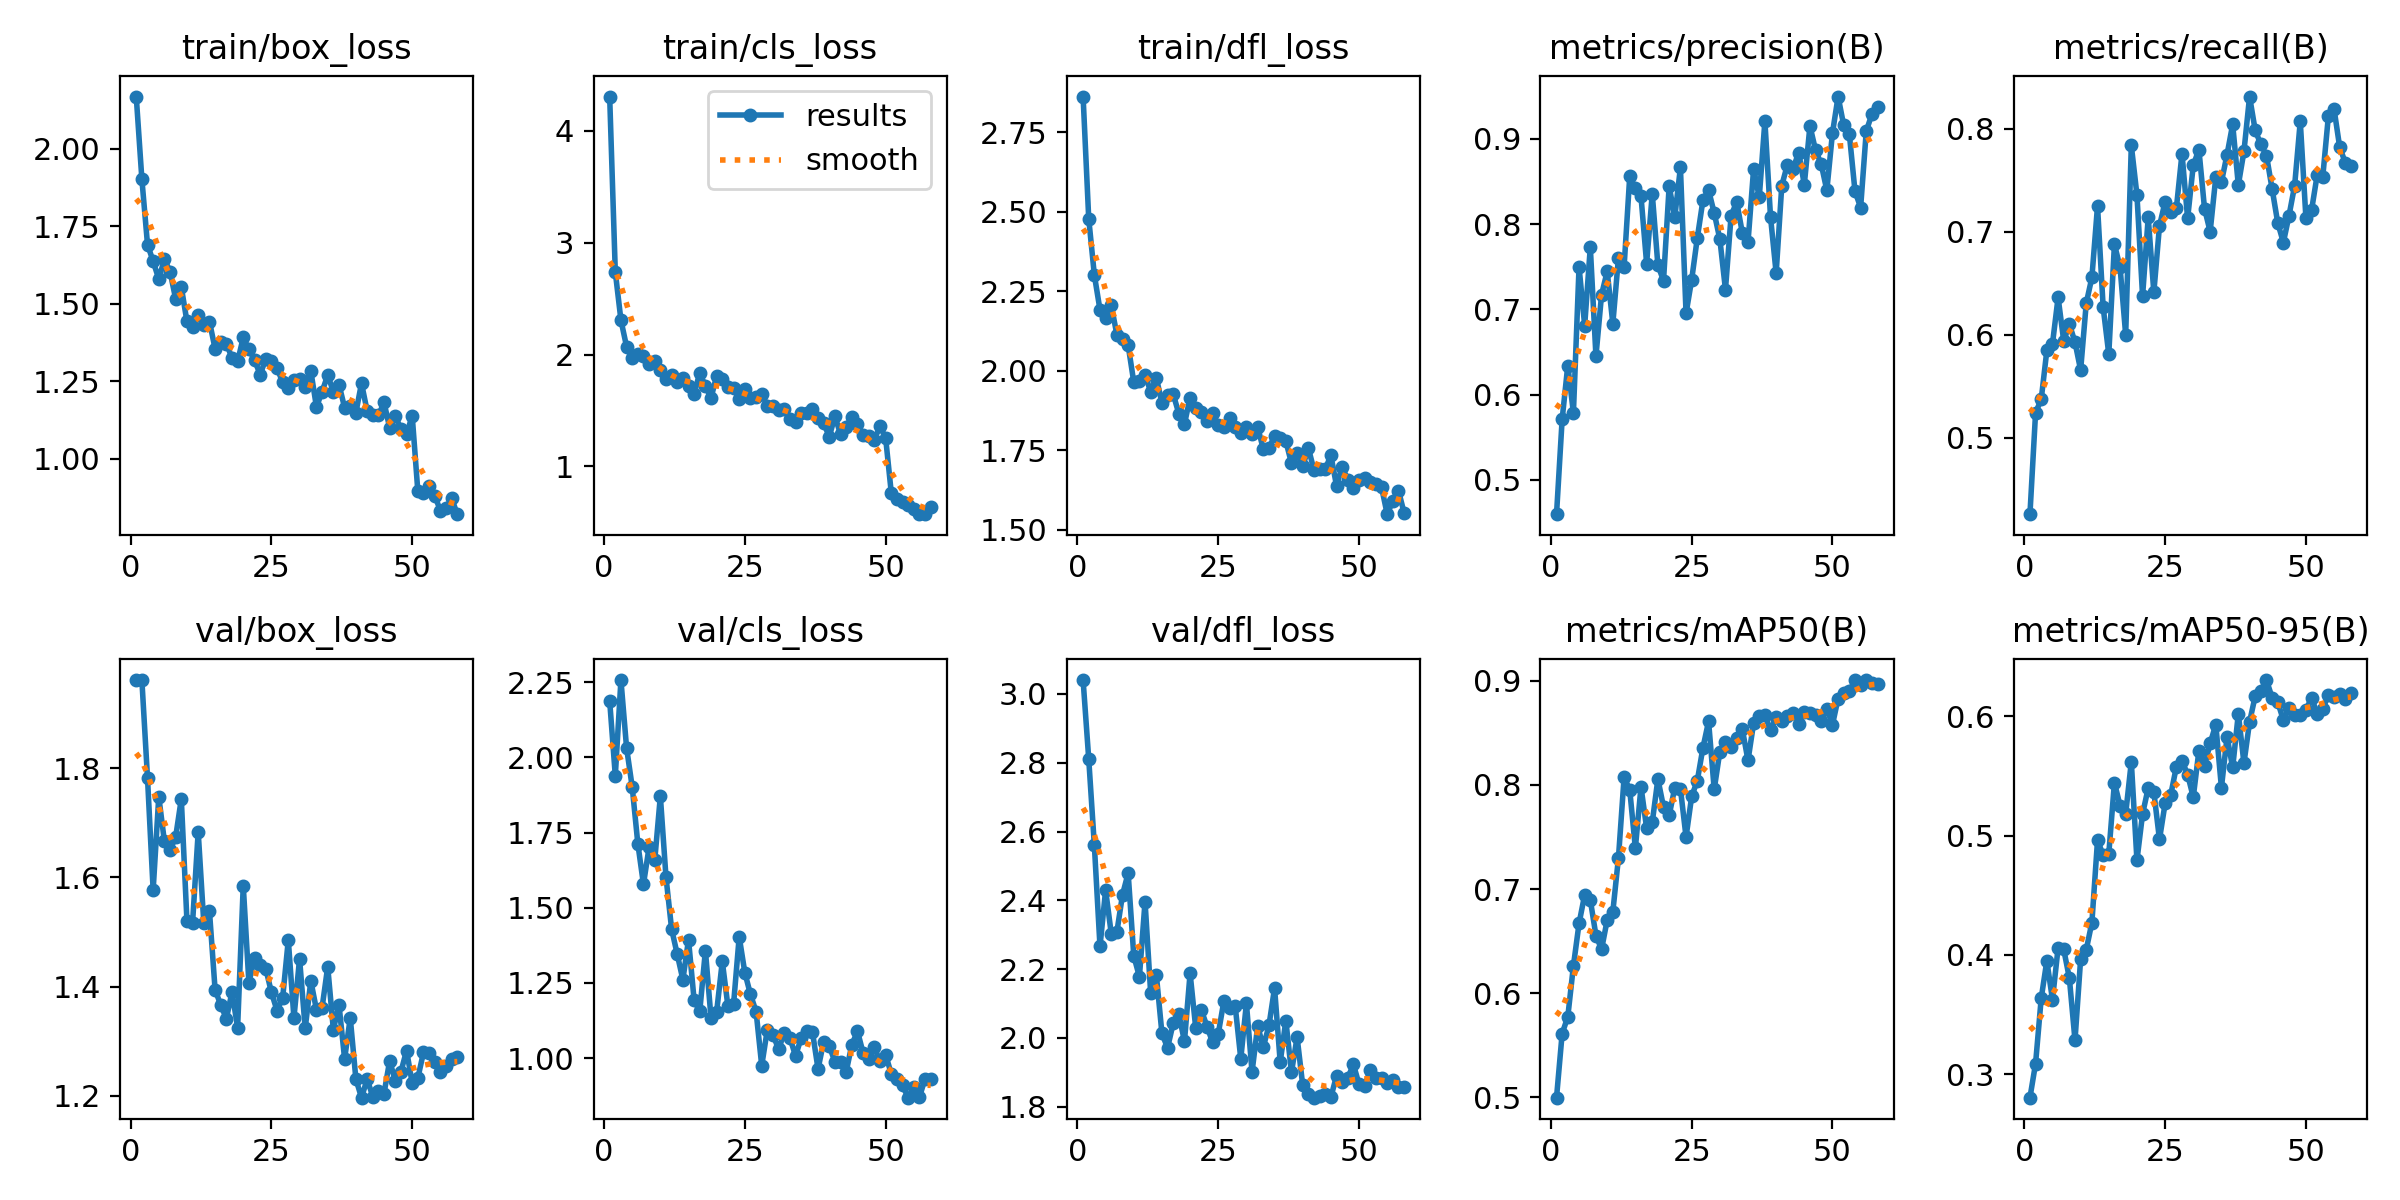

In [ ]:
from IPython.display import Image as IPImage

IPImage(filename=f"{run_dir}/results.png")

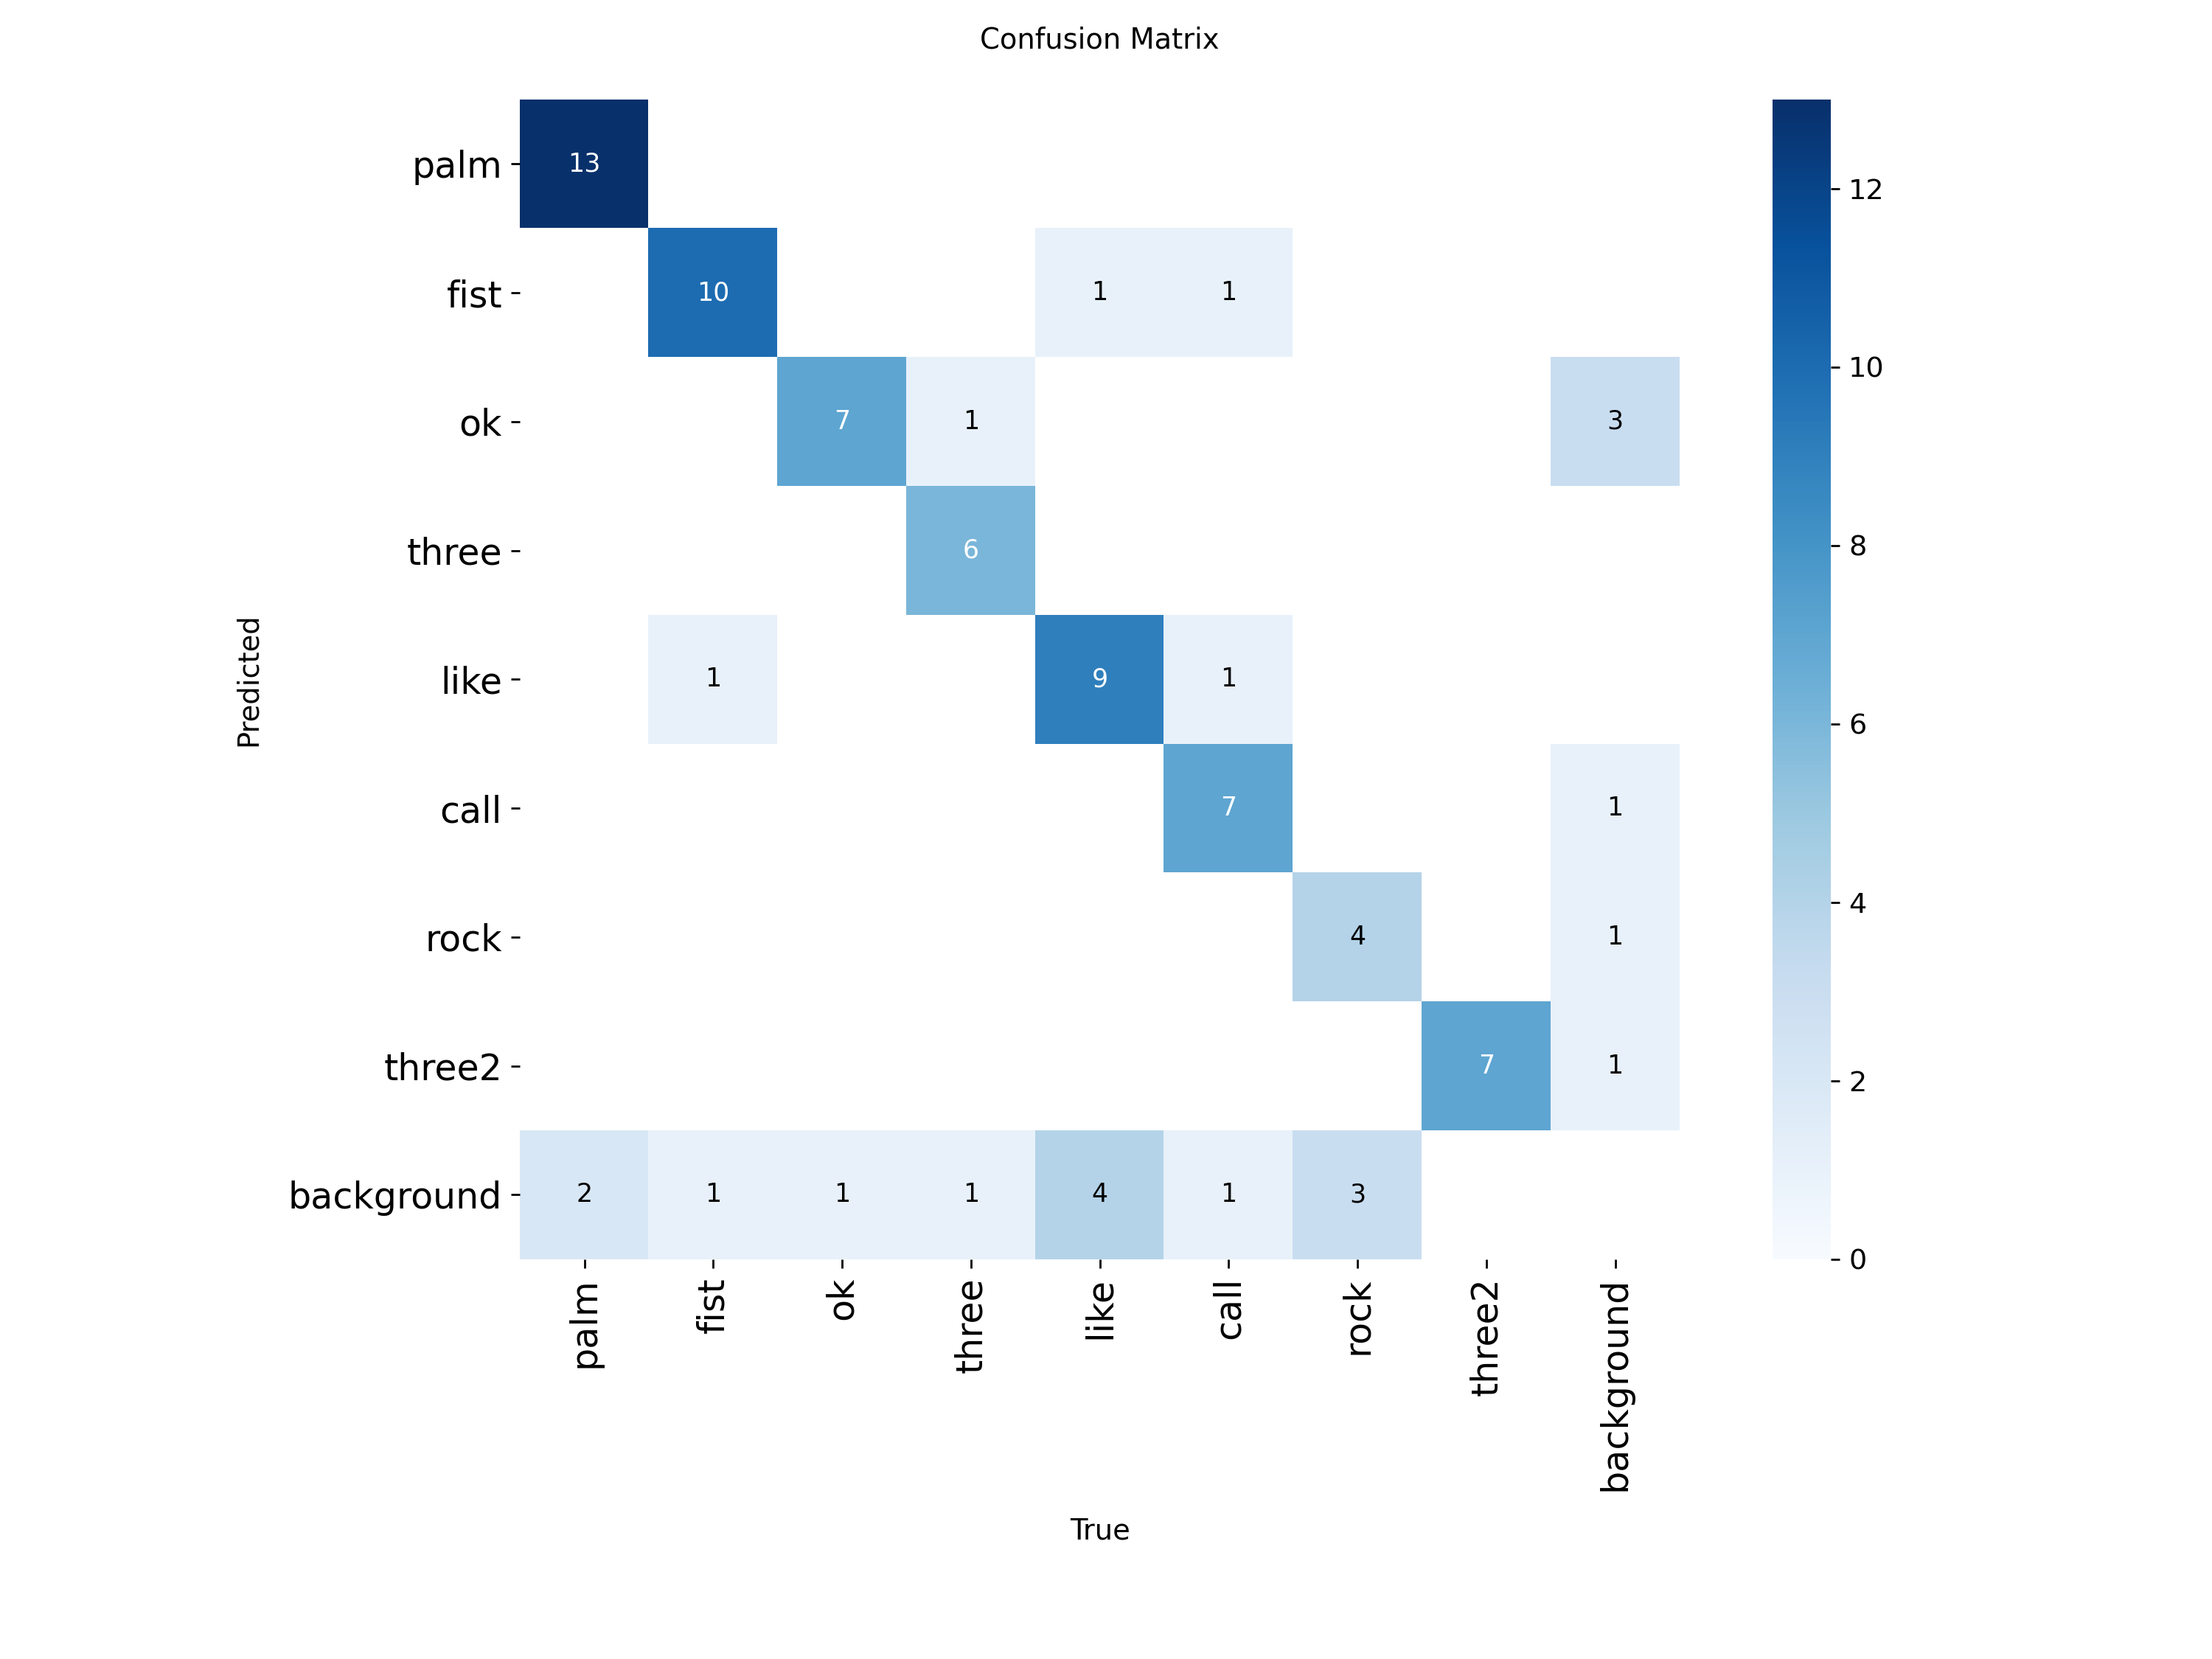

In [ ]:
IPImage(filename=f"{run_dir}/confusion_matrix.png")

## 6. 검증셋 평가

In [ ]:
best_model = YOLO(f"{weights_dir}/best.pt")
metrics = best_model.val(data=DATASET_YAML)

print("\n=== 검증 결과 ===")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,266,728 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1594.3±408.5 MB/s, size: 54.5 KB)
val: Scanning /content/data/elderly_yolo_converted/labels/val.cache... 78 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 20.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.2it/s 1.6s
                   all         78         81      0.923      0.759      0.873      0.637
                  palm         13         15          1      0.838      0.865      0.686
                  fist         12         12      0.874      0.833      0.859      0.587
                    ok          8          8      0.792      0.875      0.888      0.685
                 three          8          8      0.934       0.75      0.828      0.586
                  like         

## 7. 노인 손 테스트 이미지로 추론 확인

In [ ]:
import glob

test_images = glob.glob(f"{LOCAL_DATA_DIR}/images/test/*.jpg")[:5]

if test_images:
    test_results = best_model.predict(test_images, save=True, conf=0.4)
    print(f"\n추론 결과 저장 위치: {test_results[0].save_dir}")
else:
    print("테스트 이미지를 찾지 못함. 경로를 확인할 것.")


0: 640x640 1 palm, 1 fist, 10.4ms
1: 640x640 1 rock, 10.4ms
2: 640x640 1 rock, 10.4ms
3: 640x640 1 three2, 10.4ms
4: 640x640 1 rock, 10.4ms
Speed: 2.4ms preprocess, 10.4ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

추론 결과 저장 위치: /content/runs/detect/predict


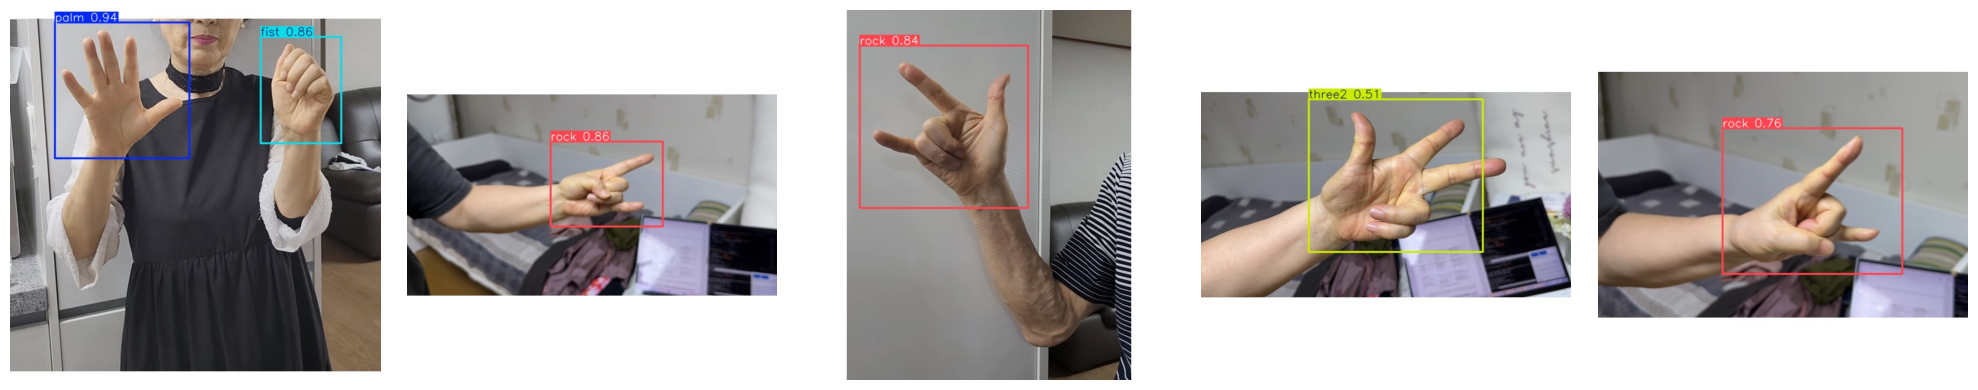

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

if test_images:
    save_dir = test_results[0].save_dir
    saved_files = sorted(os.listdir(save_dir))

    n = len(saved_files)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, fname in zip(axes, saved_files):
        img = mpimg.imread(os.path.join(save_dir, fname))
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 8. 가중치 Google Drive 백업

In [ ]:
import shutil

DRIVE_SAVE_DIR = "/content/drive/MyDrive/HandSpark"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

shutil.copy(f"{weights_dir}/best.pt", f"{DRIVE_SAVE_DIR}/hagrid_stage2_elderly_best.pt")
print(f"저장됨: {DRIVE_SAVE_DIR}/hagrid_stage2_elderly_best.pt")

저장됨: /content/drive/MyDrive/HandSpark/hagrid_stage2_elderly_best.pt
